In [ ]:
pip install torch torchvision

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [ ]:
import kagglehub
import os
os.environ['KAGGLE_USERNAME'] = 'mayuri2015'
os.environ['KAGGLE_KEY'] = 'KGAT_cc7442c7960f9fdab000bd3614b59668' # Replace 'tu_clave' with your actual Kaggle API key

# 2. You have not accepted the competition rules for the 'cifar-10' competition on Kaggle.
#    Please visit https://kaggle.com/competitions/cifar-10/rules and accept them if you haven't already.
# After verifying your key and accepting the rules, try running this cell again.

# Download latest version
path = kagglehub.dataset_download("fedesoriano/cifar10-python-in-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10-python-in-csv' dataset.
Path to dataset files: /kaggle/input/cifar10-python-in-csv


In [ ]:
class VGG16(nn.Module):
    def __init__(self, num_classes=1000):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
            # Softmax eliminado: CrossEntropyLoss ya lo incluye internamente
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def load_cifar10_dataset(batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

Forma de salida: torch.Size([1, 1000])


In [ ]:
vgg_16 = VGG16(num_classes=10).to(device)

train_loader, test_loader = load_cifar10_dataset(batch_size=64)

learning_rate = 0.001
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_16.parameters(), lr=learning_rate)

# La solución es eliminar el argumento 'verbose', ya que no existe en versiones actuales de PyTorch
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo actual: {device}')

if device.type == 'cpu':
    print('\nAVISO: Estás usando la CPU. El entrenamiento de VGG16 será extremadamente lento.')
    print('Ve a Entorno de ejecución -> Cambiar tipo de entorno de ejecución y selecciona T4 GPU.')

Dispositivo actual: cuda


In [ ]:
# Training and Validation loop with Scheduler
for epoch in range(num_epochs):
    vgg_16.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation Block
    vgg_16.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg_16(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total

    # Actualizar el scheduler basado en la pérdida de validación
    scheduler.step(avg_val_loss)

    print(f'Epoch [{epoch + 1}/{num_epochs}]')
    print(f'Train Loss: {epoch_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {accuracy:.2f}%')
    print(f'LR actual: {optimizer.param_groups[0]["lr"]}')
    print('-' * 30)

Epoch [1/10]
Train Loss: 2.3030 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.001
------------------------------
Epoch [2/10]
Train Loss: 2.3027 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.001
------------------------------
Epoch [3/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.001
------------------------------
Epoch [4/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.0005
------------------------------
Epoch [5/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.0005
------------------------------
Epoch [6/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.0005
------------------------------
Epoch [7/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.00025
------------------------------
Epoch [8/10]
Train Loss: 2.3026 | Val Loss: 2.3026 | Val Accuracy: 10.00%
LR actual: 0.00025
------------------------------
Epoch [9/10]
Trai

### Análisis del Modelo: Matriz de Confusión
Este bloque generará una matriz para visualizar el desempeño por cada categoría.

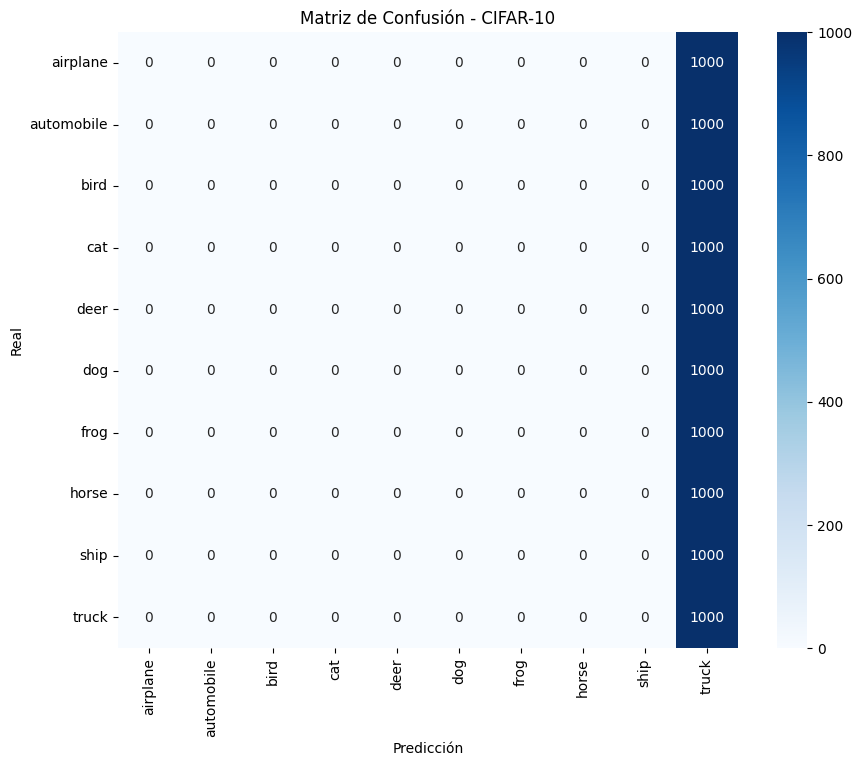


Reporte de Clasificación:
              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.00      0.00      0.00      1000
       horse       0.00      0.00      0.00      1000
        ship       0.00      0.00      0.00      1000
       truck       0.10      1.00      0.18      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Nombres de las clases de CIFAR-10
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    # Calcular matriz
    cm = confusion_matrix(all_labels, all_preds)

    # Graficar
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión - CIFAR-10')
    plt.show()

    # Mostrar reporte de métricas
    print("\nReporte de Clasificación:")
    print(classification_report(all_labels, all_preds, target_names=classes))

# Ejecutar análisis (asegúrate de que el modelo esté entrenado)
plot_confusion_matrix(vgg_16, test_loader, device)